![visioncolab](https://drive.google.com/uc?export=view&id=10UMKqKSnU2grmitxYxvL7V6GVMu8RrpP)


`Google colab's for image processing, pattern recognition and computer vision`

[Domingo Mery](https://domingomery.ing.puc.cl/) - Department of Computer Science - Universidad Católica de Chile

# BASIC EXAMPLE FOR OCR

In this (very simple) example, there are two characters: 0 and 1... zeros and ones!

The idea is to build a classifier that can recognize the character. This general task is known as OCR (optical character recognition).

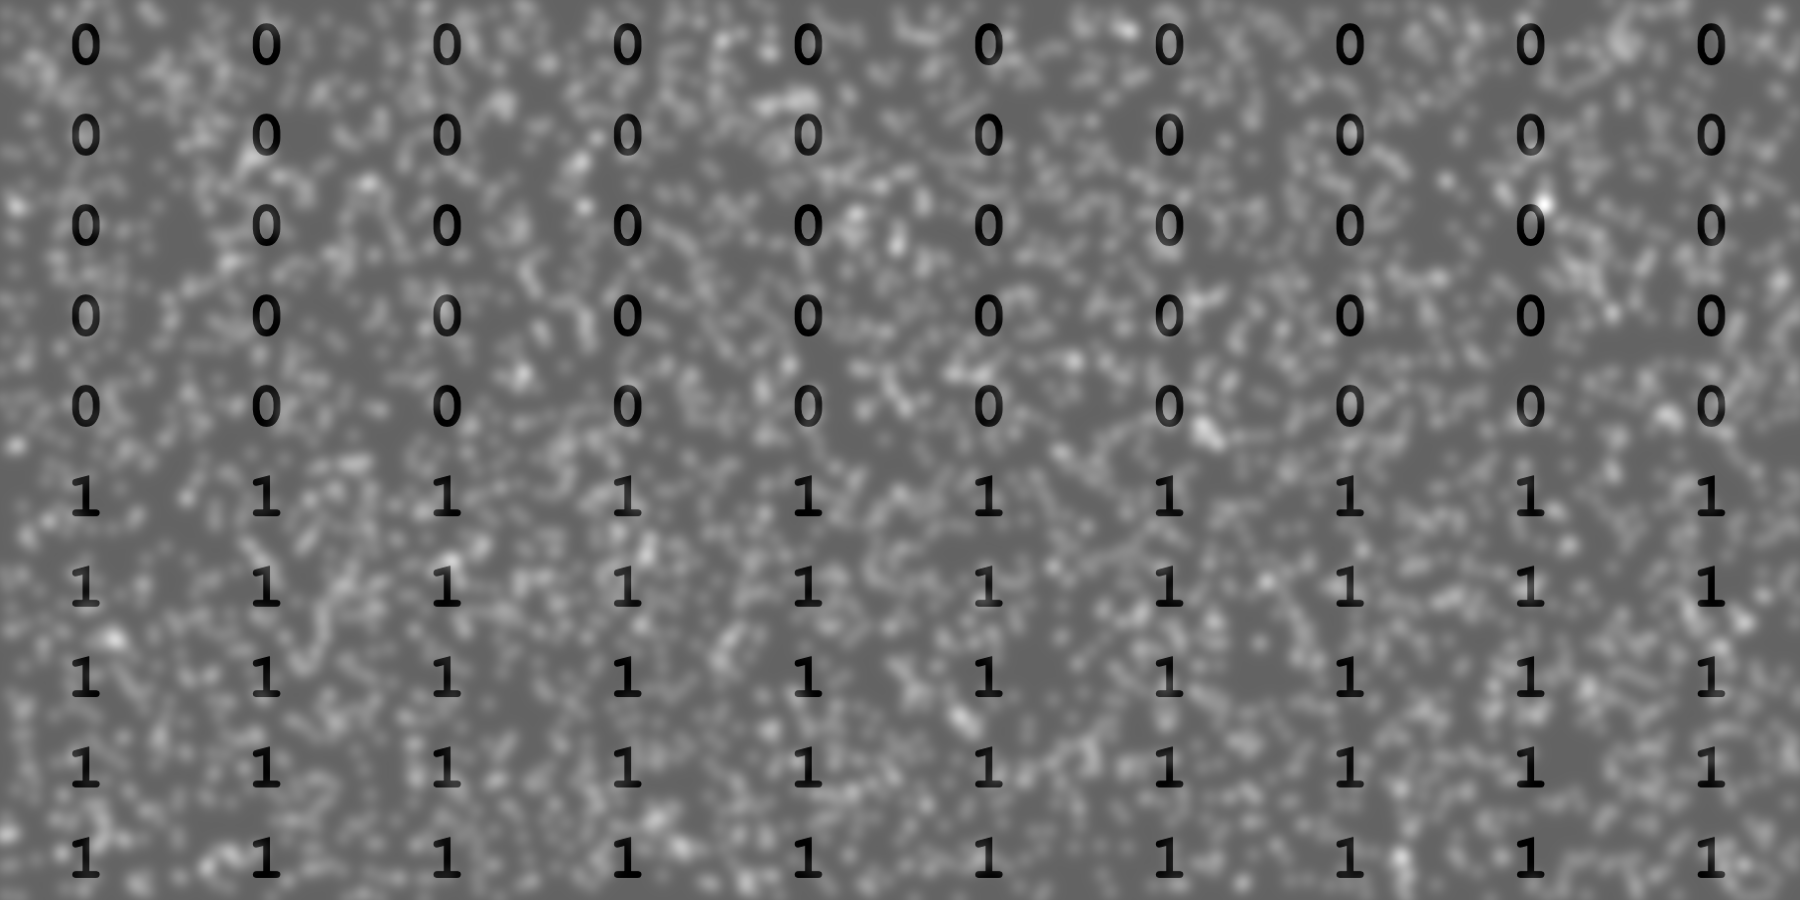

# 0 Initial Setup

In [ ]:
# For calculation
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Functions for image reading

def num2fixstr(x,d):
    # input: (21,5)
    # output: '00021'
    st = '%0*d' % (d,x)
    return st

def str2(x):
  s = '{:.2f}'.format(x)
  return s


In [ ]:
def plot_confusion_matrix(C):
    """
    Plot a confusion matrix using seaborn.

    Parameters:
        C (numpy.ndarray): A 2D numpy array representing the confusion matrix.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(C, annot=True, fmt='.0f', cmap='Blues', cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
def fill_holes(binary_image):
    """
    Fill holes in a binary image.
    A hole is defined as a background region that is surrounded by foreground pixels.

    Parameters:
        binary_image (numpy.ndarray): A 2D binary NumPy array (0s and 1s).

    Returns:
        numpy.ndarray: Binary image with holes filled.
    """
    # Ensure input is binary (0 and 1 only)
    binary_image = (binary_image > 0).astype(np.uint8)

    # Create a padded version of the image to handle boundary cases
    padded = np.pad(binary_image, pad_width=1, mode='constant', constant_values=0)

    # Create a mask for background areas
    filled = np.zeros_like(padded, dtype=np.uint8)
    filled[0, 0] = 1  # Start flood-fill from the top-left corner

    # Structuring element for 4-connectivity (up, down, left, right)
    shifts = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Flood-fill algorithm
    while True:
        new_filled = filled.copy()
        for dx, dy in shifts:
            new_filled |= np.roll(filled, shift=dx, axis=0)
            new_filled |= np.roll(filled, shift=dy, axis=1)

        # Only allow propagation where the original padded image is background
        new_filled &= (padded == 0)

        if np.array_equal(filled, new_filled):
            break  # Stop when no new changes
        filled = new_filled

    # The holes are the complement of the flooded region inside the padded area
    holes_filled = np.where(filled[1:-1, 1:-1] == 0, 1, binary_image)

    return holes_filled

# 1 Image Loading and Database Definition

There are 50 images per character.

* The images of the character 0 are stored in img_00_xxx.png.

* The images of the character 1 are stored in img_01_xxx.png

where xxx = 001, 002, ..., 050

In [ ]:
!wget https://www.dropbox.com/scl/fi/5wwrq5ptfo6pqxvitqjul/zerosones.png?rlkey=19hzz1myoi39iiav7nnp7wkor
!mv zerosones.png?rlkey=19hzz1myoi39iiav7nnp7wkor zerosones.png

--2026-03-10 14:39:32--  https://www.dropbox.com/scl/fi/5wwrq5ptfo6pqxvitqjul/zerosones.png?rlkey=19hzz1myoi39iiav7nnp7wkor
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uce735dca4dc26f4943c002bf756.dl.dropboxusercontent.com/cd/0/inline/C8Z03weYZLTBH7KF6bMN8Pd3CYtL6r8vzC6hWES1Xsf7TrYvhA_knqcK4Q91UiTuJcKIB7o1brNlDgEy2BQ1W6hvLp8Qhidj2gbdnI3-6gAW6dFLKkp4gv-1rcL7e5j_dxA/file# [following]
--2026-03-10 14:39:33--  https://uce735dca4dc26f4943c002bf756.dl.dropboxusercontent.com/cd/0/inline/C8Z03weYZLTBH7KF6bMN8Pd3CYtL6r8vzC6hWES1Xsf7TrYvhA_knqcK4Q91UiTuJcKIB7o1brNlDgEy2BQ1W6hvLp8Qhidj2gbdnI3-6gAW6dFLKkp4gv-1rcL7e5j_dxA/file
Resolving uce735dca4dc26f4943c002bf756.dl.dropboxusercontent.com (uce735dca4dc26f4943c002bf756.dl.dropboxusercontent.com)... 162.125.81.15, 2620:100:6031:15::a27d:510f
Connecting to u

In [ ]:
# Directory for the original images
!mkdir img

In [ ]:
I = plt.imread('zerosones.png')
t = 0
c = 0
for i in range(10):
  for j in range(10):
    t = t+1
    Iij = I[90*i:90*(i+1),180*j:180*(j+1)]
    fimg  = 'img/img_'+num2fixstr(c,2)+'_'+num2fixstr(t,3)+'.png'
    plt.imsave(fimg,Iij,cmap='gray')
    if t==50:
      c = c+1
      t = 0

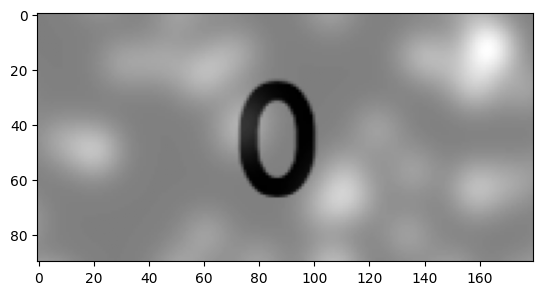

In [ ]:
# Reading an image with a 0 : img/img_00_043.png

img    = plt.imread('img/img_00_043.png')
implot = plt.imshow(img,cmap='gray')


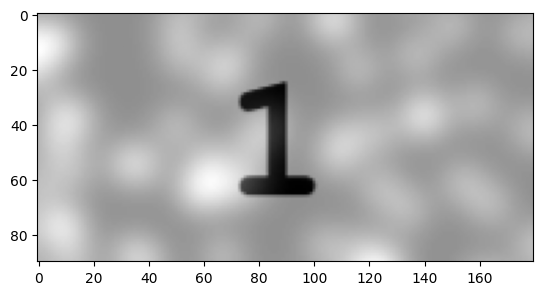

In [ ]:
# Reading an image with a 1 : img/img_01_003.png

img    = plt.imread('img/img_01_003.png')
implot = plt.imshow(img,cmap='gray')


# 2 Feature Extraction

We will extract two different geometric features: Aspect and Normalized Area

## 2.0 Segmentation

First, it is necessary to segement the characters... then we can extract gemetric features.

In [ ]:
!mkdir seg # Directory for the segmented images

In [ ]:
ths = 0.4 # Threshold for the segmentation
K   = 2   # number of classes
N   = 50  # number of images per class

for j in range(K):     # for each class
  for i in range(N):   # for each image of the class j
    st   = num2fixstr(j,2)+'_'+num2fixstr(i+1,3)+'.png'
    fimg = 'img/img_'+st
    fseg = 'seg/seg_'+st
    Iij  = plt.imread(fimg)
    Sij  = (Iij[:,:,0] < ths)*255
    plt.imsave(fseg,Sij.astype('uint8'),cmap='gray')
    Sij  = plt.imread(fseg)


## 2.1.1 Aspect

It is defined as the ratio between height (h) and width (w) of the chracter. That is:

Aspect = h/w

where h and w are given in pixels.

In [ ]:
def Aspect(S,echo='off'):

  if len(S.shape)>2:
    S = S[:,:,0]

  # If image has multiple channels (RGBA), use the first one for segmentation
  R = S>0                 # Binary image of the segmentation

  # (i,j) coordinates of the pixels that belong to the region
  ij = np.argwhere(R)
  if len(ij) == 0:
      return 0

  ii = ij[:,0]
  jj = ij[:,1]

  # width
  w = np.max(jj)-np.min(jj)+1

  # height
  h = np.max(ii)-np.min(ii)+1

  # Aspect
  x = h/w

  if echo=='on':
    # Convert boolean to float/int to avoid Matplotlib dtype errors
    plt.imshow(R.astype(float), cmap='gray')
    print('height = '+str(h)+' pixels')
    print(' width = '+str(w)+' pixels')
    print('aspect = '+str(x))

  return x

height = 42 pixels
 width = 28 pixels
aspect = 1.5


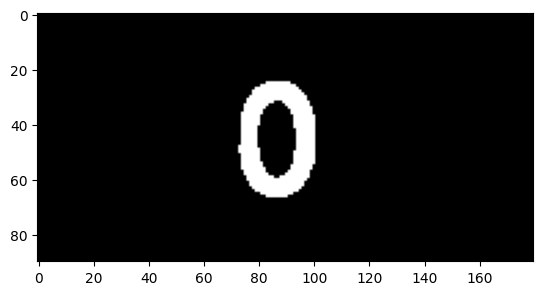

In [ ]:
# Example of the aspect of a charcater 0
seg0    = plt.imread('seg/seg_00_043.png')
aspect0 = Aspect(seg0,echo='on')


height = 41 pixels
 width = 28 pixels
aspect = 1.4642857142857142


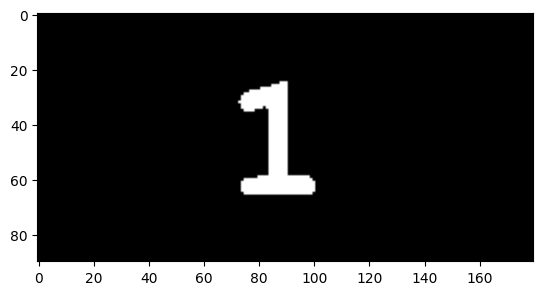

In [ ]:
# Example of the aspect of a character 1

seg1    = plt.imread('seg/seg_01_003.png')
aspect1 = Aspect(seg1,echo='on')

## 2.1.2 Normalized Area

The normalized area is defined as follows:

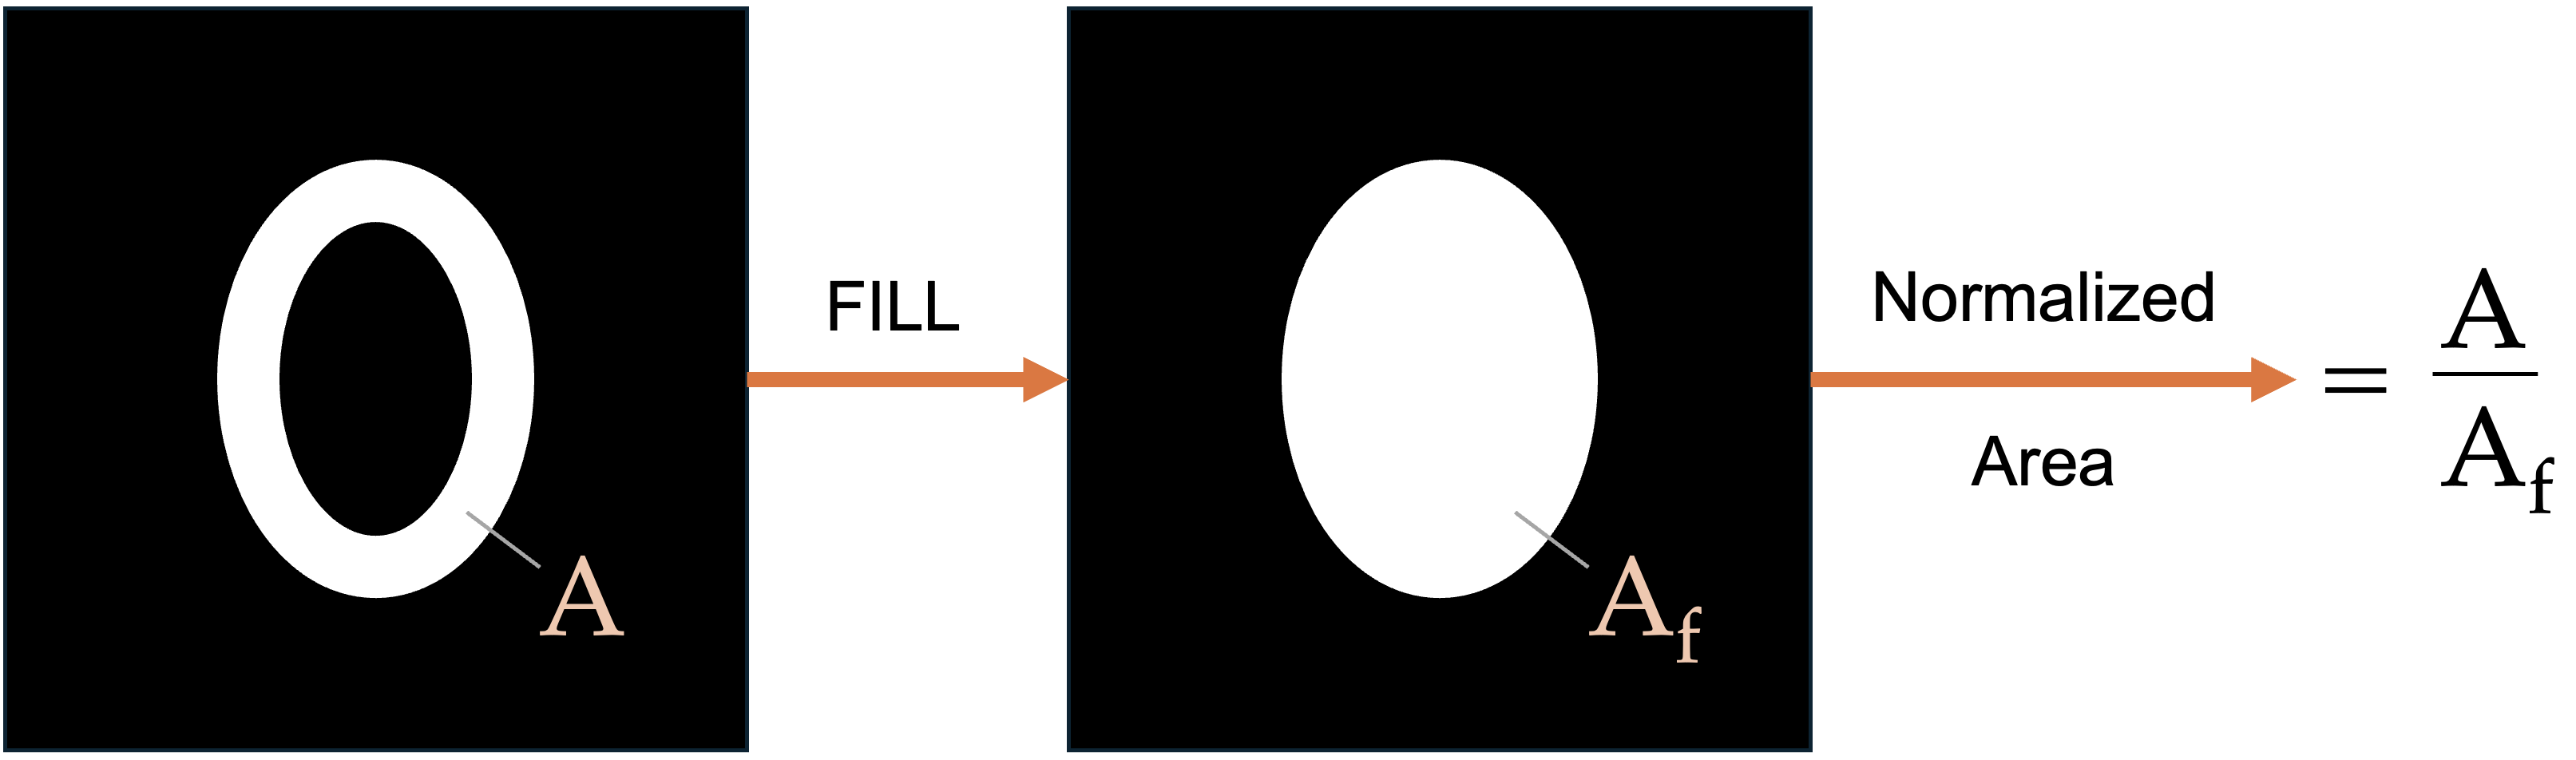

The filled character for 'O' is larger in pixels than the filled character '1'. The feature to extract is the normalized area, defined as the number of pixels of the character (filled, with no holes), $A$, divided by the filled area $A_f$. This feature is a number between 0 and 1, it is invariant to the size of the character, and invariant to the size of the image.


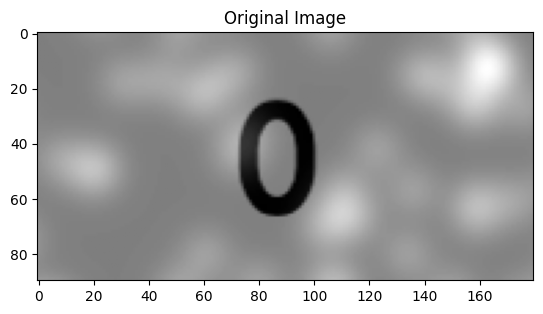

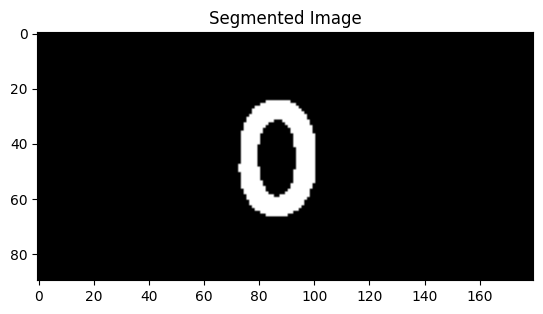

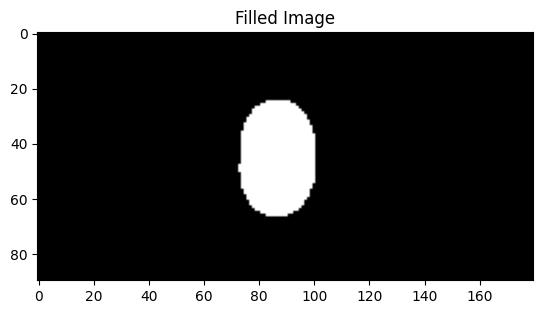

In [ ]:
# Example of filling of a charcater 0

img0   = plt.imread('img/img_00_043.png')
implot = plt.imshow(img0,cmap='gray')
plt.title('Original Image')
plt.show()

seg0    = plt.imread('seg/seg_00_043.png')
implot  = plt.imshow(seg0,cmap='gray')
plt.title('Segmented Image')
plt.show()

segf    = fill_holes(seg0[:,:,0]>0)
implot  = plt.imshow(segf,cmap='gray')
plt.title('Filled Image')
plt.show()


In [ ]:
def NormalizedArea(S,echo='off'):

  if len(S.shape)>2:
    S = S[:,:,0]

  # If image has multiple channels (RGBA), use the first one for segmentation
  R = S>0                 # Binary image of the segmentation


  Rf = fill_holes(R).astype(int) # filled region (with no holes)

  # Area
  A  = np.sum(R)
  Af = np.sum(Rf)


  # Normalized area
  if Af == 0: # Avoid division by zero if width or height is 0
      a = 0.0
  else:
      a = A/Af

  if echo=='on':
    implot = plt.imshow(R,cmap='gray')
    print('normalized area = '+str(a))
  return a

normalized area = 0.6873065015479877


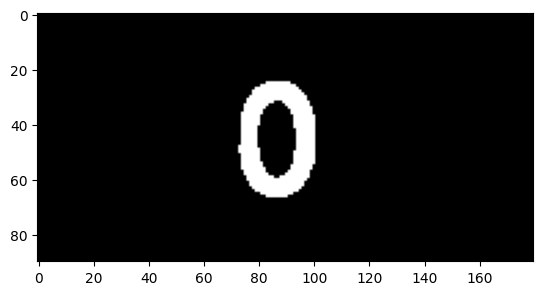

In [ ]:
# Example of the normalized area of a charcater 0

seg0   = plt.imread('seg/seg_00_043.png')
AreaN0 = NormalizedArea(seg0,echo='on')


normalized area = 1.0


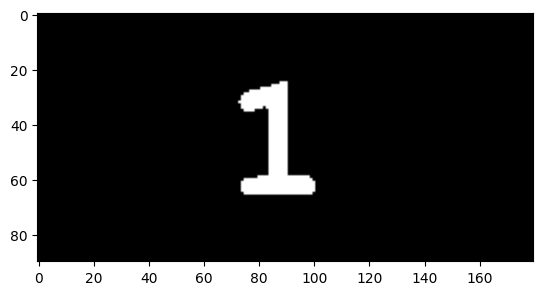

In [ ]:
# Example of the normalized area of a charcater 1

img1   = plt.imread('seg/seg_01_003.png')
AreaN1 = NormalizedArea(img1,echo='on')


## 2.2 Extraction for all images

In [ ]:
# Feature extraction in all images
# Class 0 = '0' : Class 1 = '1'

K = 2  # number of classes
N = 50 # number of images per class

X = np.zeros((N*K,2)) # features (aspect,normalized area)
Y = np.zeros((N*K,)) # label (ideal classification)

t = 0 # counter
for j in range(K):     # for each class
  print('Extracting features for class ',j,'...')
  for i in range(N):   # for each image of the class j

    # Image reading
    st   = num2fixstr(j,2)+'_'+num2fixstr(i+1,3)+'.png'
    fseg = 'seg/seg_'+st
    Sij = plt.imread(fseg)

    # Feature extraction
    X[t,0] = Aspect(Sij)
    X[t,1] = NormalizedArea(Sij)
    Y[t] = j

    t = t+1


Extracting features for class  0 ...
Extracting features for class  1 ...


# 3 Feature Selection
Now, we have to decide wich features are relevant, that means which features are able to separate both classes. In this example, the selection is performed manually.

In [ ]:
# The classes are two: class 0 and class 1

X0 = X[0:50,:]
X1 = X[50:100,:]

# Statistics for Aspect
x0_max0  = np.max(X0[:,0])
x1_max0  = np.max(X1[:,0])

x0_min0  = np.min(X0[:,0])
x1_min0  = np.min(X1[:,0])

x0_mean0 = np.mean(X0[:,0])
x1_mean0 = np.mean(X1[:,0])


# Statistics for Normalized Area
x0_max1 = np.max(X0[:,1])
x1_max1 = np.max(X1[:,1])

x0_min1  = np.min(X0[:,1])
x1_min1  = np.min(X1[:,1])

x0_mean1 = np.mean(X0[:,1])
x1_mean1 = np.mean(X1[:,1])


print('Statistics of the extracted features for each feature (Aspect,NormalizedArea):')

print('Class 0:')
print('>>>> min  = ('+str2(x0_min0) +','+str2(x0_min1)+')')
print('>>>> mean = ('+str2(x0_mean0)+','+str2(x0_mean1)+')')
print('>>>> max  = ('+str2(x0_max0) +','+str2(x0_max1)+')')
print(' ')
print('Class 1:')
print('>>>> min  = ('+str2(x1_min0) +','+str2(x1_min1)+')')
print('>>>> mean = ('+str2(x1_mean0)+','+str2(x1_mean1)+')')
print('>>>> max  = ('+str2(x1_max0) +','+str2(x1_max1)+')')



Statistics of the extracted features for each feature (Aspect,NormalizedArea):
Class 0:
>>>> min  = (0.50,0.64)
>>>> mean = (1.50,0.69)
>>>> max  = (1.59,1.00)
 
Class 1:
>>>> min  = (1.43,1.00)
>>>> mean = (1.49,1.00)
>>>> max  = (1.58,1.00)


Distribution for Aspect


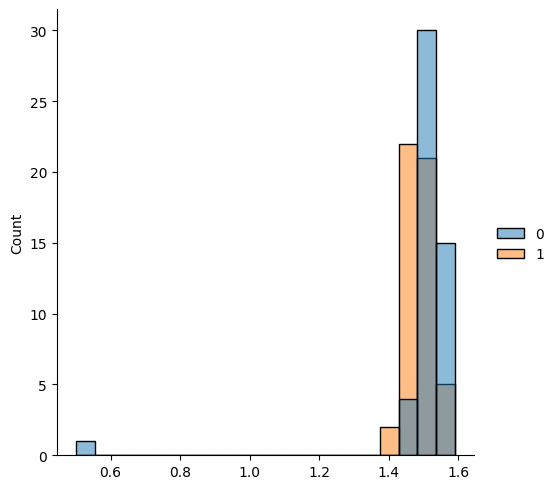

Distribution for Normalized Area


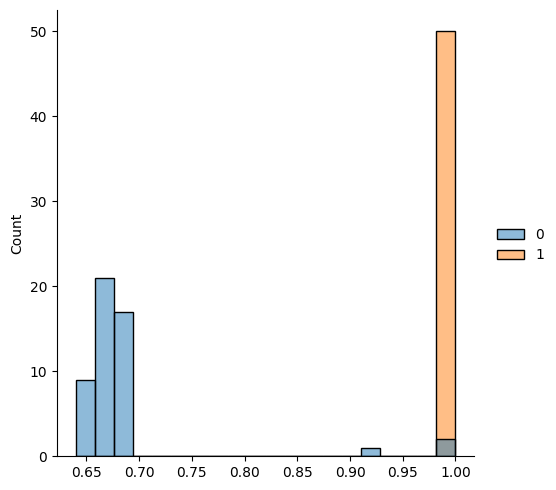

In [ ]:
# Distribution per class for each feature (Aspect,NormalizedArea)
feature_st = ['Aspect','Normalized Area']
for k in range(2):
  print('Distribution for '+feature_st[k])
  s = sns.displot([X0[:,k],X1[:,k]],bins=20)
  plt.show()


It is clear that the second feature (Normalized Area) is enough to separate both classes.


# 4 Classification

The classification can be done using a threshold (thc) calculated as the average of the means of the selected feature for each class.

In [ ]:
thc = (x0_mean1 + x1_mean1)/2

print('thc = '+str2(thc))

thc = 0.84


In [ ]:
# Classification of all samples
Yc = (X[:,1]>thc).astype('uint8') # Class 0 if x is less than or equal to the threshold, Class 1 otherwise.

In [ ]:
# Clasification in Testing subset
Y0 = Yc[0:50]   # Classification of 0
Y1 = Yc[50:100] # Classification of 1


In [ ]:
# Classification of samples '1'
Y1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=uint8)

In [ ]:
# Classification of samples '0'
Y0

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8)

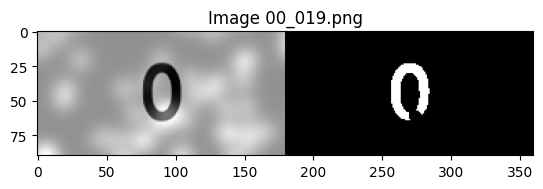

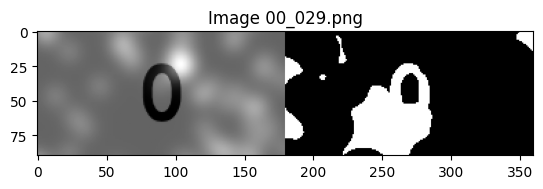

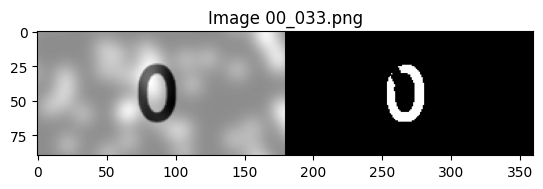

In [ ]:
# Mis-Classification in training set of '0'
ii = np.argwhere(Y0)
j = 0
for k in range(len(ii)):
    i = ii[k][0]
    st   = num2fixstr(j,2)+'_'+num2fixstr(i+1,3)+'.png'
    fimg = 'img/img_'+st
    fseg = 'seg/seg_'+st
    Iij = plt.imread(fimg)
    Sij = plt.imread(fseg)
    plt.imshow(np.concatenate((Iij,Sij),axis=1))
    plt.title('Image '+st)
    plt.show()

# 5 Evaluation

## 5.1 Evaluation in training susbset

In [ ]:
# Correctly classified characters
True0   = np.sum(Y0==0)
True1   = np.sum(Y1==1)

# Erroneously classified characters
False0  = np.sum(Y0==1)
False1  = np.sum(Y1==0)

# Confusion matrix MC[i,j] =
#                  characters of class i classified as class j
MC      = np.zeros((2,2))
MC[0,0] = True0
MC[0,1] = False0
MC[1,0] = False1
MC[1,1] = True1

# Accuracy: percentage of correct predictions made by a model
AccTest     = (True0+True1)/(True0+False0+False1+True1)*100

print('Testing Confusion Matrix:')
print(MC[0,:])
print(MC[1,:])

print('')
print('Testing Accuracy = '+str(AccTest)+'%')

Testing Confusion Matrix:
[47.  3.]
[ 0. 50.]

Testing Accuracy = 97.0%


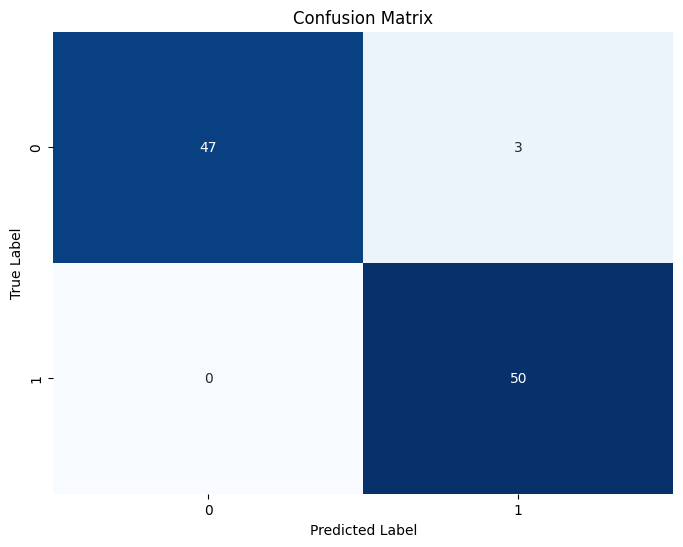

In [ ]:
plot_confusion_matrix(MC)

## 5.2 Evaluation in a testing image

Now, we evaluate the performance of our classification algorithm on a new image (testing image). This image wasn't used during the training process.

In [ ]:
!wget https://www.dropbox.com/scl/fi/yocq5dcq0opfgyssw8zju/zero.png?rlkey=fzb7cmnvi3djkyidrr6furmer
!cp zero.png?rlkey=fzb7cmnvi3djkyidrr6furmer zero.png

--2026-03-10 14:49:08--  https://www.dropbox.com/scl/fi/yocq5dcq0opfgyssw8zju/zero.png?rlkey=fzb7cmnvi3djkyidrr6furmer
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uca945e838faa9a13781bc1103ce.dl.dropboxusercontent.com/cd/0/inline/C8YxruNNdm4vLm_sAax0-CKwUO5vsAvyrzKVDUutUjrPaz96ald1qPanPZMwv8p7rvh8I6qdSiW6M3GLxa3GjtGOW40OGECl82awvmr5CK5dq9oRAWM3r0HI9frzNDBnTn8/file# [following]
--2026-03-10 14:49:09--  https://uca945e838faa9a13781bc1103ce.dl.dropboxusercontent.com/cd/0/inline/C8YxruNNdm4vLm_sAax0-CKwUO5vsAvyrzKVDUutUjrPaz96ald1qPanPZMwv8p7rvh8I6qdSiW6M3GLxa3GjtGOW40OGECl82awvmr5CK5dq9oRAWM3r0HI9frzNDBnTn8/file
Resolving uca945e838faa9a13781bc1103ce.dl.dropboxusercontent.com (uca945e838faa9a13781bc1103ce.dl.dropboxusercontent.com)... 162.125.81.15, 2620:100:6035:15::a27d:550f
Connecting to uca945

In [ ]:
!wget https://www.dropbox.com/scl/fi/hb8ywbs8k7gts1szzp1om/one.png?rlkey=u0ohjtnit2gr1re5yrow33ghc
!cp one.png?rlkey=u0ohjtnit2gr1re5yrow33ghc one.png

--2026-03-10 14:49:12--  https://www.dropbox.com/scl/fi/hb8ywbs8k7gts1szzp1om/one.png?rlkey=u0ohjtnit2gr1re5yrow33ghc
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6035:18::a27d:5512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc4388de3fed0bc6c6513fc0418d.dl.dropboxusercontent.com/cd/0/inline/C8bMFz5Ho3P-kqLfDrFfa5Fs3bxTdICu9UmOuS0MjGxtYdYc10qEXoaDXWp6wGQalooEHpVxYCcbne3oWt1bOOm9Ykd-phFFyNWi4qyyJeA2qBXaeNgt81FB1mhLguhKTWE/file# [following]
--2026-03-10 14:49:13--  https://uc4388de3fed0bc6c6513fc0418d.dl.dropboxusercontent.com/cd/0/inline/C8bMFz5Ho3P-kqLfDrFfa5Fs3bxTdICu9UmOuS0MjGxtYdYc10qEXoaDXWp6wGQalooEHpVxYCcbne3oWt1bOOm9Ykd-phFFyNWi4qyyJeA2qBXaeNgt81FB1mhLguhKTWE/file
Resolving uc4388de3fed0bc6c6513fc0418d.dl.dropboxusercontent.com (uc4388de3fed0bc6c6513fc0418d.dl.dropboxusercontent.com)... 162.125.81.15, 2620:100:6030:15::a27d:500f
Connecting to uc4388d

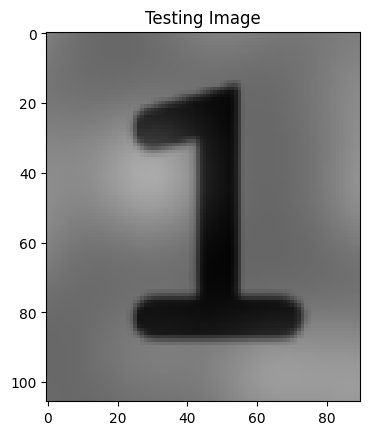

In [ ]:
# 1. Load Image
# Itest = plt.imread('zero.png')
Itest = plt.imread('one.png')
plt.imshow(Itest)
plt.title('Testing Image')
plt.show()

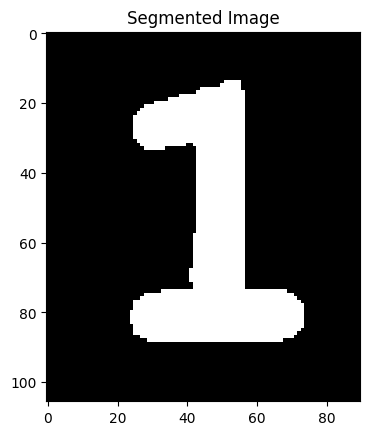

In [ ]:
# 2. Segmentation
S = (Itest[:,:,0]< ths)*255
plt.imshow(S,cmap='gray')
plt.title('Segmented Image')
plt.show()


In [ ]:
# 3. Extraction of normalized area
x = NormalizedArea(S)
print('Normalized Area = '+str2(x))

Normalized Area = 1.00


In [ ]:
# 4 Classification

y = x>thc

print('Classification = '+str(y*1))


Classification = 1
